This notebook takes a burst image from each full time series and uses it to construct patches that contain at least 50% of data. This allows us to not train on chips that are complete nodata.

In [1]:
import geopandas as gpd
import rasterio
import pandas as pd
from shapely.geometry import box
import backoff
from requests.exceptions import HTTPError
import requests
import io
import numpy as np
from rasterio.io import MemoryFile
from rasterio.warp import transform_bounds
from rasterio.crs import CRS
from rasterio.transform import xy
from pathlib import Path
from mpire import WorkerPool

# Parameters

In [4]:
PATCH_SIZE = 256
STRIDE = 224
PERCENT_COVERED = .50

PATCH_DATA_DIR = f'patches_{PATCH_SIZE}'

In [5]:
PATCH_DATA_DIR = Path(PATCH_DATA_DIR)
PATCH_DATA_DIR.mkdir(exist_ok=True, parents=True)

# Generating Patches

In [6]:
df_burst_ts = gpd.read_parquet('burst_ts.parquet')

In [8]:
df_burst_single = df_burst_ts.groupby('jpl_burst_id').first().reset_index(drop=False)
df_burst_single.head()

,jpl_burst_id,opera_id,acq_dt,acq_date_for_mgrs_pass,polarizations,track_number,pass_id,url_crosspol,url_copol,geometry
0,T001-000054-IW1,OPERA_L2_RTC-S1_T001-000054-IW1_20220108T18030...,2022-01-08 18:03:08+00:00,None,VV+VH,1,488,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,"POLYGON ((1.54238 9.60217, 2.30972 9.75694, 2...."
1,T001-000055-IW1,OPERA_L2_RTC-S1_T001-000055-IW1_20220108T18031...,2022-01-08 18:03:11+00:00,None,VV+VH,1,488,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,"POLYGON ((1.50714 9.76884, 2.27589 9.9237, 2.2..."
2,T001-000056-IW1,OPERA_L2_RTC-S1_T001-000056-IW1_20220108T18031...,2022-01-08 18:03:13+00:00,None,VV+VH,1,488,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,"POLYGON ((1.4727 9.93567, 2.24374 10.09079, 2...."
3,T001-000056-IW2,OPERA_L2_RTC-S1_T001-000056-IW2_20220108T18031...,2022-01-08 18:03:14+00:00,None,VV+VH,1,488,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,"POLYGON ((2.20969 10.14346, 3.01705 10.30376, ..."
4,T001-000057-IW1,OPERA_L2_RTC-S1_T001-000057-IW1_20220108T18031...,2022-01-08 18:03:16+00:00,None,VV+VH,1,488,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,"POLYGON ((1.43707 10.10226, 2.20859 10.25727, ..."


In [9]:
@backoff.on_exception(backoff.expo, (HTTPError, ConnectionError), max_tries=10, max_time=60, jitter=backoff.full_jitter)
def read_bytes(
    url: str,
) -> bytes:
    resp = requests.get(url)
    data = io.BytesIO(resp.content)
    return data


def read_one_asf_dataset(url: str) -> rasterio.DatasetReader:
    img_bytes = read_bytes(url)
    memfile = MemoryFile(img_bytes, filename=url.split('/')[-1])
    dataset = memfile.open()
    dataset.memfile_obj = memfile
    return dataset

def get_utm_geo(sx, sy, transform):
    xmin, ymin = xy(transform, sy.start, sx.start)
    xmax, ymax = xy(transform, sy.stop, sx.stop)
    return box(xmin, ymin, xmax, ymax)

def get_patch_dataframe_utm(burst_id: str, 
                            stride = STRIDE,
                            patch_x = PATCH_SIZE,
                            patch_y = PATCH_SIZE,
                            percent_covered = PERCENT_COVERED) -> gpd.GeoDataFrame:
        
    
    pixels_covered_per_patch = patch_x * patch_y * percent_covered
    df_burst = df_burst_single[df_burst_single.jpl_burst_id == burst_id].reset_index(drop=True)
    url = df_burst.url_copol[0]

    ds = read_one_asf_dataset(url)
    
    data_mask = ds.read_masks(1).astype(bool)
    width = ds.width
    height = ds.height
    transform = ds.transform
    p = ds.profile
    bounds_utm = ds.bounds

    ds.close()
        
    bounds_ll = transform_bounds(p['crs'], CRS.from_epsg(4326), *bounds_utm)
    data_mask_f = (data_mask.astype(bool)).astype(np.uint8)
    
    n_x = width // stride + 1
    n_y = height // stride + 1
    
    slices_x = [np.s_[i * stride: i * stride + patch_x] for i in range(n_x)]
    slices_y = [np.s_[i * stride: i * stride + patch_x] for i in range(n_y)]

    patches = [(sy, sx) for sy in slices_y for sx in slices_x]
    patches_with_data = [p for p in patches if (data_mask_f[p].sum() > pixels_covered_per_patch)
                         and (data_mask_f[p].shape == (patch_x, patch_y))]

    patch_records = [{'x_start': sx.start,
                      'x_stop': sx.stop,
                      'y_start': sy.start,
                      'y_stop': sy.stop,
                      'epsg': p['crs'].to_epsg(),
                      'burst_id': burst_id,
                      'geometry': get_utm_geo(sx, sy, transform)} for (sy, sx) in patches_with_data]

    df = pd.DataFrame(patch_records)
    df = gpd.GeoDataFrame(df, geometry=df.geometry, crs=p['crs'])
    return df

# Example

In [10]:
burst_id_ex = df_burst_single.jpl_burst_id.iloc[0]
burst_id_ex

'T001-000054-IW1'

In [11]:
df_sample = get_patch_dataframe_utm(burst_id_ex)

In [12]:
df_sample.shape

(40, 7)

<Axes: >

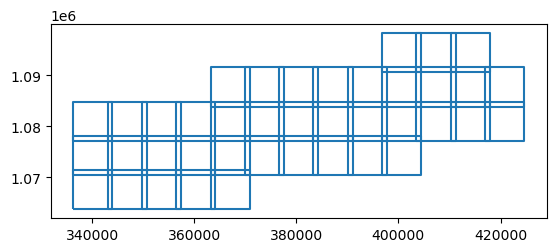

In [13]:
df_sample_plot = df_sample.copy()
df_sample_plot.geometry = df_sample_plot.geometry.boundary
df_sample_plot.plot()

# Automate and Serialize

In [14]:
def get_patches_and_serialize(burst_id: str) -> Path:
    out_path = PATCH_DATA_DIR / f'{burst_id}.parquet'
    if not out_path.exists():
        df = get_patch_dataframe_utm(burst_id)
        df.to_parquet(out_path, compression='zstd', index=None)
    return out_path

In [15]:
burst_ids = df_burst_single.jpl_burst_id.unique().tolist()

In [16]:
with WorkerPool(n_jobs=10, use_dill=True) as pool:
    paths = pool.map(
        get_patches_and_serialize, (bid for bid in burst_ids), 
        progress_bar=True, 
        iterable_len=len(burst_ids)
    )

100%|██████████████████████████████████████| 2671/2671 [14:31<00:00,  1.13s/it]
